In [ ]:
Prompt: 
I have a CSV file called petrignanos.csv. 
Please read it and give me:
1. The column names and data types
2. The date range
3. How many missing values each column has
4. A quick statistical summary of the numeric columns

In [1]:
import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv('Petrignano.csv')

# 1. Column names and data types
print('='*60)
print('1. COLUMN NAMES AND DATA TYPES')
print('='*60)
print(df.dtypes)
print()

# 2. Date range
print('='*60)
print('2. DATE RANGE')
print('='*60)
date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
if date_cols:
    for col in date_cols:
        print(f'{col}: {df[col].min()} to {df[col].max()}')
else:
    print('No datetime columns found.')
    for col in df.columns:
        if 'date' in col.lower() or 'time' in col.lower():
            print(f'Possible date column: {col}')
            print(f'  Sample values: {df[col].head(3).tolist()}')
print()

# 3. Missing values per column
print('='*60)
print('3. MISSING VALUES PER COLUMN')
print('='*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
for col in df.columns:
    print(f'{col:25} -> {missing[col]:5} missing ({missing_pct[col]:6.2f}%)')
print()

# 4. Statistical summary of numeric columns
print('='*60)
print('4. STATISTICAL SUMMARY OF NUMERIC COLUMNS')
print('='*60)
print(df.describe())


1. COLUMN NAMES AND DATA TYPES
Date                                        str
Rainfall_Bastia_Umbra                   float64
Depth_to_Groundwater_P25                float64
Temperature_Bastia_Umbra                float64
Temperature_Petrignano                  float64
Volume_C10_Petrignano                   float64
Hydrometry_Fiume_Chiascio_Petrignano    float64
dtype: object

2. DATE RANGE
No datetime columns found.
Possible date column: Date
  Sample values: ['1/1/2009', '2/1/2009', '3/1/2009']

3. MISSING VALUES PER COLUMN
Date                      ->     0 missing (  0.00%)
Rainfall_Bastia_Umbra     ->     0 missing (  0.00%)
Depth_to_Groundwater_P25  ->    27 missing (  0.64%)
Temperature_Bastia_Umbra  ->     0 missing (  0.00%)
Temperature_Petrignano    ->     0 missing (  0.00%)
Volume_C10_Petrignano     ->     1 missing (  0.02%)
Hydrometry_Fiume_Chiascio_Petrignano ->     0 missing (  0.00%)

4. STATISTICAL SUMMARY OF NUMERIC COLUMNS
       Rainfall_Bastia_Umbra  Depth_to_Gr

## Preprocessing for Time Series Regression

Now let's preprocess the data for time series regression analysis.

Prompt: 
Now preprocess petrignanos.csv for a time series regression problem:
1. Parse the Date column and sort chronologically
2. Replace zero values in Depth_to_Groundwater columns with NaN (they are anomalies)
3. Interpolate all missing values using linear interpolation (time-based)
4. Resample the data to monthly frequency using the mean
5. Add a 'month_sin' and 'month_cos' column to capture seasonality
6. Show the first 5 rows of the cleaned dataframe

In [5]:
import numpy as np

# Reset index if Date is already the index
if df.index.name == 'Date':
    df = df.reset_index()

# 1. Parse Date column and sort chronologically
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

print("✓ Step 1: Date parsed and data sorted chronologically")
print(f"  Date range: {df['Date'].min().date()} to {df['Date'].max().date()}\n")

# 2. Replace zero values in Depth_to_Groundwater with NaN (anomalies)
depth_cols = [col for col in df.columns if 'Depth_to_Groundwater' in col]
for col in depth_cols:
    zeros_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    print(f"✓ Step 2: Replaced {zeros_count} zeros in {col}")

print()

# 3. Set Date as index for time-based operations
df.set_index('Date', inplace=True)

# 4. Interpolate missing values using linear interpolation (time-based)
df_interpolated = df.interpolate(method='linear')
print("✓ Step 3: Missing values interpolated using linear interpolation")
print(f"  Remaining NaN values: {df_interpolated.isnull().sum().sum()}\n")

# 5. Resample to monthly frequency using mean
df_monthly = df_interpolated.resample('MS').mean()
print(f"✓ Step 4: Data resampled to monthly frequency")
print(f"  Original shape: {df.shape}")
print(f"  Monthly shape: {df_monthly.shape}\n")

# 6. Add seasonality features (month_sin and month_cos)
# Extract month from the date index (0-11 scale, then convert to radians)
month_of_year = df_monthly.index.month
df_monthly['month_sin'] = np.sin(2 * np.pi * (month_of_year - 1) / 12)
df_monthly['month_cos'] = np.cos(2 * np.pi * (month_of_year - 1) / 12)

print("✓ Step 5: Added seasonality features")
print("  - month_sin: sine component of month (0-11 scale)")
print("  - month_cos: cosine component of month (0-11 scale)\n")

# 7. Show first 5 rows of cleaned dataframe
print("="*80)
print("FIRST 5 ROWS OF PREPROCESSED DATA")
print("="*80)
print(df_monthly.head().to_string())

✓ Step 1: Date parsed and data sorted chronologically
  Date range: 2009-01-01 to 2020-06-30

✓ Step 2: Replaced 0 zeros in Depth_to_Groundwater_P25

✓ Step 3: Missing values interpolated using linear interpolation
  Remaining NaN values: 0

✓ Step 4: Data resampled to monthly frequency
  Original shape: (4199, 6)
  Monthly shape: (138, 6)

✓ Step 5: Added seasonality features
  - month_sin: sine component of month (0-11 scale)
  - month_cos: cosine component of month (0-11 scale)

FIRST 5 ROWS OF PREPROCESSED DATA
            Rainfall_Bastia_Umbra  Depth_to_Groundwater_P25  Temperature_Bastia_Umbra  Temperature_Petrignano  Volume_C10_Petrignano  Hydrometry_Fiume_Chiascio_Petrignano  month_sin     month_cos
Date                                                                                                                                                                                               
2009-01-01               0.203226                -30.503871                  4.964516  

## Building Supervised Learning Dataset

Create a lagged feature dataset for time series regression.

In [14]:
# Create lagged features for t-1 and t-2
# We'll create lags for ALL columns in df_monthly

df_lagged = df_monthly.copy()

# Create lag-1 features (previous month)
for col in df_monthly.columns:
    df_lagged[f'{col}_lag1'] = df_monthly[col].shift(1)

# Create lag-2 features (two months ago)
for col in df_monthly.columns:
    df_lagged[f'{col}_lag2'] = df_monthly[col].shift(2)

print("✓ Created lagged features for lags 1 and 2")
print(f"  Total columns after lagging: {df_lagged.shape[1]}")
print()

# Drop rows with NaN (first 2 rows will have NaN from lagging)
df_lagged_clean = df_lagged.dropna()

print(f"✓ Dropped rows with NaN from lagging")
print(f"  Original shape: {df_lagged.shape}")
print(f"  Clean shape: {df_lagged_clean.shape}\n")

# Define target and features
# y = Depth_to_Groundwater_P25 at time t (current month)
y = df_lagged_clean['Depth_to_Groundwater_P25']

# X = all lagged features (lag1 and lag2 columns)
lag_columns = [col for col in df_lagged_clean.columns if '_lag1' in col or '_lag2' in col]
X = df_lagged_clean[lag_columns]

print("="*80)
print("SUPERVISED LEARNING DATASET CREATED")
print("="*80)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}\n")

print("Target variable (y): Depth_to_Groundwater_P25 at time t")
print(f"Features (X): {len(lag_columns)} lagged features (t-1 and t-2)\n")

print("="*80)
print("FIRST 3 ROWS OF FEATURE MATRIX (X)")
print("="*80)
print(X.head(3).to_string())

✓ Created lagged features for lags 1 and 2
  Total columns after lagging: 24

✓ Dropped rows with NaN from lagging
  Original shape: (138, 24)
  Clean shape: (136, 24)

SUPERVISED LEARNING DATASET CREATED
X shape: (136, 16)
y shape: (136,)

Target variable (y): Depth_to_Groundwater_P25 at time t
Features (X): 16 lagged features (t-1 and t-2)

FIRST 3 ROWS OF FEATURE MATRIX (X)
            Rainfall_Bastia_Umbra_lag1  Depth_to_Groundwater_P25_lag1  Temperature_Bastia_Umbra_lag1  Temperature_Petrignano_lag1  Volume_C10_Petrignano_lag1  Hydrometry_Fiume_Chiascio_Petrignano_lag1  month_sin_lag1  month_cos_lag1  Rainfall_Bastia_Umbra_lag2  Depth_to_Groundwater_P25_lag2  Temperature_Bastia_Umbra_lag2  Temperature_Petrignano_lag2  Volume_C10_Petrignano_lag2  Hydrometry_Fiume_Chiascio_Petrignano_lag2  month_sin_lag2  month_cos_lag2
Date                                                                                                                                                                 

Prompt:
Using the cleaned monthly dataframe, build a supervised learning dataset:
- The target variable y is 'Depth_to_Groundwater_P25' at month t
- The features X are ALL columns (including the target) at months t-1 and t-2 (2-month lag)
- Name the lagged columns with suffixes '_lag1' and '_lag2'
- Drop any rows with NaN that result from the lagging
- Print the shape of X and y, and show the first 3 rows of X

In [15]:
# Quick verification
print("\n" + "="*80)
print("DATASET SUMMARY")
print("="*80)
print(f"Feature matrix X: {X.shape[0]} samples × {X.shape[1]} features")
print(f"Target vector y: {y.shape[0]} samples")
print(f"\nFirst 3 feature names (lag1):")
print([col for col in X.columns[:3]])
print(f"\nLast 3 feature names (lag2):")
print([col for col in X.columns[-3:]])
print(f"\nTarget variable statistics:")
print(y.describe())


DATASET SUMMARY
Feature matrix X: 136 samples × 16 features
Target vector y: 136 samples

First 3 feature names (lag1):
['Rainfall_Bastia_Umbra_lag1', 'Depth_to_Groundwater_P25_lag1', 'Temperature_Bastia_Umbra_lag1']

Last 3 feature names (lag2):
['Hydrometry_Fiume_Chiascio_Petrignano_lag2', 'month_sin_lag2', 'month_cos_lag2']

Target variable statistics:
count    136.000000
mean     -25.108389
std        2.918296
min      -33.586774
25%      -26.645484
50%      -25.040844
75%      -23.271855
max      -19.320667
Name: Depth_to_Groundwater_P25, dtype: float64


In [16]:
print("\n" + "="*80)
print("FIRST 3 ROWS OF FEATURE MATRIX X")
print("="*80)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(X.head(3))


FIRST 3 ROWS OF FEATURE MATRIX X
            Rainfall_Bastia_Umbra_lag1  Depth_to_Groundwater_P25_lag1  \
Date                                                                    
2009-03-01                    0.500000                     -29.350000   
2009-04-01                    1.103226                     -28.502903   
2009-05-01                    0.543333                     -27.736333   

            Temperature_Bastia_Umbra_lag1  Temperature_Petrignano_lag1  \
Date                                                                     
2009-03-01                       5.125000                     4.792857   
2009-04-01                       9.254839                     8.716129   
2009-05-01                      13.806667                    13.250000   

            Volume_C10_Petrignano_lag1  \
Date                                     
2009-03-01               -25641.174857   
2009-04-01               -28374.874839   
2009-05-01               -28167.667200   

            Hydrom

## Model Selection & Evaluation with Cross-Validation

Complete ML pipeline with multiple CV strategies and hyperparameter tuning.

Prompt: 
Now write the complete Python script from the assignment, using the X and y we just built.
The script must include:

1. Hard split: 80% train / 20% test, NO shuffle (chronological order preserved)
2. Two CV strategies: KFold(n_splits=5, shuffle=True) and TimeSeriesSplit(n_splits=5)
3. A fixed Pipeline with StandardScaler + DecisionTreeRegressor(max_depth=10)
4. cross_val_score for both strategies
5. Final fit on train, evaluate on test
6. The evaluate_model_selection() function with GridSearchCV testing max_depth values [2, 5, 10, 20]
7. Call evaluate_model_selection() with both CV strategies
8. Print all results clearly

Use sklearn. Add comments explaining each section.


In [10]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

print("="*80)
print("MACHINE LEARNING PIPELINE: MODEL SELECTION & EVALUATION")
print("="*80)
print()

# ============================================================================
# SECTION 1: HARD TRAIN/TEST SPLIT (80/20) - NO SHUFFLE (CHRONOLOGICAL)
# ============================================================================
print("SECTION 1: TRAIN/TEST SPLIT (80/20, chronological order)")
print("-" * 80)

# Calculate split point
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Chronological order: PRESERVED (no shuffle)")
print()

# ============================================================================
# SECTION 2: DEFINE CV STRATEGIES
# ============================================================================
print("SECTION 2: CROSS-VALIDATION STRATEGIES")
print("-" * 80)

# CV Strategy 1: Standard KFold with shuffle
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
print("CV Strategy 1: KFold(n_splits=5, shuffle=True)")
print("  - Use case: For independent, non-temporal data")
print("  - Mixing order: Shuffles data across folds")
print()

# CV Strategy 2: TimeSeriesSplit (respects temporal order)
cv_timeseries = TimeSeriesSplit(n_splits=5)
print("CV Strategy 2: TimeSeriesSplit(n_splits=5)")
print("  - Use case: For time series data (sequential training)")
print("  - Mixing order: Growing window approach preserves temporal structure")
print()

# ============================================================================
# SECTION 3: CREATE BASELINE PIPELINE
# ============================================================================
print("SECTION 3: BASELINE PIPELINE")
print("-" * 80)

# Pipeline: StandardScaler + DecisionTreeRegressor
pipeline_baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))
])

print("Pipeline Components:")
print("  1. StandardScaler: normalize features to zero mean & unit variance")
print("  2. DecisionTreeRegressor: max_depth=10 (baseline hyperparameter)")
print()

# ============================================================================
# SECTION 4: CROSS-VALIDATION SCORES
# ============================================================================
print("SECTION 4: CROSS-VALIDATION SCORES (on training set)")
print("-" * 80)

# CV Score with KFold
cv_scores_kfold = cross_val_score(
    pipeline_baseline, X_train, y_train, 
    cv=cv_kfold, 
    scoring='r2'
)

print(f"\nKFold CV Results (R² score):")
print(f"  Fold scores: {np.array2string(cv_scores_kfold, precision=4, separator=', ')}")
print(f"  Mean R²: {cv_scores_kfold.mean():.4f} (+/- {cv_scores_kfold.std():.4f})")

# CV Score with TimeSeriesSplit
cv_scores_ts = cross_val_score(
    pipeline_baseline, X_train, y_train, 
    cv=cv_timeseries, 
    scoring='r2'
)

print(f"\nTimeSeriesSplit CV Results (R² score):")
print(f"  Fold scores: {np.array2string(cv_scores_ts, precision=4, separator=', ')}")
print(f"  Mean R²: {cv_scores_ts.mean():.4f} (+/- {cv_scores_ts.std():.4f})")
print()

# ============================================================================
# SECTION 5: FINAL MODEL FITTING & TEST EVALUATION
# ============================================================================
print("SECTION 5: FINAL MODEL - FIT ON TRAIN, EVALUATE ON TEST")
print("-" * 80)

# Fit on training data
pipeline_baseline.fit(X_train, y_train)

# Predictions
y_train_pred = pipeline_baseline.predict(X_train)
y_test_pred = pipeline_baseline.predict(X_test)

# Evaluate
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nTraining Set Performance:")
print(f"  MSE:  {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")

print(f"\nTest Set Performance:")
print(f"  MSE:  {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")
print()

# ============================================================================
# SECTION 6: HYPERPARAMETER TUNING WITH GRIDSEARCHCV
# ============================================================================
print("SECTION 6: HYPERPARAMETER TUNING (GridSearchCV)")
print("-" * 80)

def evaluate_model_selection(cv_strategy, cv_name):
    """
    Perform GridSearchCV with multiple max_depth values for DecisionTreeRegressor.
    
    Parameters:
    -----------
    cv_strategy : cross-validation splitter object (KFold or TimeSeriesSplit)
    cv_name : str, name of the CV strategy for display
    """
    
    print(f"\n>>> GridSearchCV with {cv_name}:")
    print(f"    Testing max_depth values: [2, 5, 10, 20]")
    
    # Define parameter grid
    param_grid = {
        'regressor__max_depth': [2, 5, 10, 20]
    }
    
    # GridSearchCV
    grid_search = GridSearchCV(
        pipeline_baseline,
        param_grid,
        cv=cv_strategy,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    
    # Fit on training data
    grid_search.fit(X_train, y_train)
    
    # Extract results
    best_params = grid_search.best_params_
    best_cv_score = grid_search.best_score_
    
    # Get best model and evaluate on test
    best_model = grid_search.best_estimator_
    y_test_pred_best = best_model.predict(X_test)
    test_r2_best = r2_score(y_test, y_test_pred_best)
    test_rmse_best = np.sqrt(mean_squared_error(y_test, y_test_pred_best))
    
    print(f"\n    Results:")
    print(f"    Best max_depth: {best_params['regressor__max_depth']}")
    print(f"    Best CV R² (mean): {best_cv_score:.4f}")
    print(f"    Test R²: {test_r2_best:.4f}")
    print(f"    Test RMSE: {test_rmse_best:.4f}")
    
    # Show all fold results
    print(f"\n    Detailed CV Results for each max_depth:")
    results_df = pd.DataFrame(grid_search.cv_results_)
    for idx, row in results_df.iterrows():
        max_d = row['param_regressor__max_depth']
        mean_score = row['mean_test_score']
        std_score = row['std_test_score']
        print(f"      max_depth={max_d:2d}: {mean_score:.4f} (+/- {std_score:.4f})")
    
    return grid_search

# ============================================================================
# SECTION 7: EXECUTE HYPERPARAMETER TUNING FOR BOTH CV STRATEGIES
# ============================================================================
print()

grid_search_kfold = evaluate_model_selection(cv_kfold, "KFold")
grid_search_timeseries = evaluate_model_selection(cv_timeseries, "TimeSeriesSplit")

print()
print("="*80)
print("SUMMARY: CV STRATEGY COMPARISON")
print("="*80)
print("\nKFold Strategy:")
print(f"  Best max_depth: {grid_search_kfold.best_params_['regressor__max_depth']}")
print(f"  Best CV R²: {grid_search_kfold.best_score_:.4f}")
print(f"  Test R² (best model): {r2_score(y_test, grid_search_kfold.best_estimator_.predict(X_test)):.4f}")

print("\nTimeSeriesSplit Strategy:")
print(f"  Best max_depth: {grid_search_timeseries.best_params_['regressor__max_depth']}")
print(f"  Best CV R²: {grid_search_timeseries.best_score_:.4f}")
print(f"  Test R² (best model): {r2_score(y_test, grid_search_timeseries.best_estimator_.predict(X_test)):.4f}")

print("\nConclusion:")
print("  - TimeSeriesSplit better respects temporal structure for time series data")
print("  - KFold may produce overoptimistic CV scores due to data mixing")
print("  - Compare both strategies for final model selection")
print("="*80)

MACHINE LEARNING PIPELINE: MODEL SELECTION & EVALUATION

SECTION 1: TRAIN/TEST SPLIT (80/20, chronological order)
--------------------------------------------------------------------------------
Training set size: 108 samples (79.4%)
Test set size: 28 samples (20.6%)
Chronological order: PRESERVED (no shuffle)

SECTION 2: CROSS-VALIDATION STRATEGIES
--------------------------------------------------------------------------------
CV Strategy 1: KFold(n_splits=5, shuffle=True)
  - Use case: For independent, non-temporal data
  - Mixing order: Shuffles data across folds

CV Strategy 2: TimeSeriesSplit(n_splits=5)
  - Use case: For time series data (sequential training)
  - Mixing order: Growing window approach preserves temporal structure

SECTION 3: BASELINE PIPELINE
--------------------------------------------------------------------------------
Pipeline Components:
  1. StandardScaler: normalize features to zero mean & unit variance
  2. DecisionTreeRegressor: max_depth=10 (baseline hy

In [17]:
print("\n" + "="*80)
print("QUICK SUMMARY OF RESULTS")
print("="*80)
print(f"\n✓ Train/Test Split: {X_train.shape[0]}/{X_test.shape[0]} (80/20 chronological)")
print(f"✓ Baseline Model (max_depth=10):")
print(f"    - Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
print(f"\n✓ KFold GridSearchCV:")
print(f"    - Best max_depth: {grid_search_kfold.best_params_['regressor__max_depth']}")
print(f"    - Best CV R²: {grid_search_kfold.best_score_:.4f}")
print(f"\n✓ TimeSeriesSplit GridSearchCV:")
print(f"    - Best max_depth: {grid_search_timeseries.best_params_['regressor__max_depth']}")
print(f"    - Best CV R²: {grid_search_timeseries.best_score_:.4f}")


QUICK SUMMARY OF RESULTS

✓ Train/Test Split: 108/28 (80/20 chronological)
✓ Baseline Model (max_depth=10):
    - Train R²: 1.0000, Test R²: -0.3371

✓ KFold GridSearchCV:
    - Best max_depth: 20
    - Best CV R²: 0.8981

✓ TimeSeriesSplit GridSearchCV:
    - Best max_depth: 5
    - Best CV R²: 0.2255


## Visualization: Model Performance & Predictions

Prompt: 
Create a visualization with 2 subplots:
1. Bar chart comparing: Naive CV score, Temporal CV score, and Final Test R2
2. Line chart showing actual vs predicted Depth_to_Groundwater_P25 values on the test set (using the best temporal model)
Add a title and clear labels. Save as 'results.png'

Creating visualizations...

✓ Visualization saved as 'results.png'

VISUALIZATION SUMMARY

Subplot 1 - Model Performance Comparison:
  • Naive CV (KFold): 0.8975
  • Temporal CV (TimeSeriesSplit): 0.0028
  • Final Test R² (Best Temporal Model): -0.3183

Subplot 2 - Actual vs Predicted:
  • Number of test samples: 28
  • Prediction RMSE: 0.9626
  • Prediction MAE: 0.7458

✓ Chart components: Bar chart (left), Line chart (right)
✓ Saved location: results.png (current working directory)


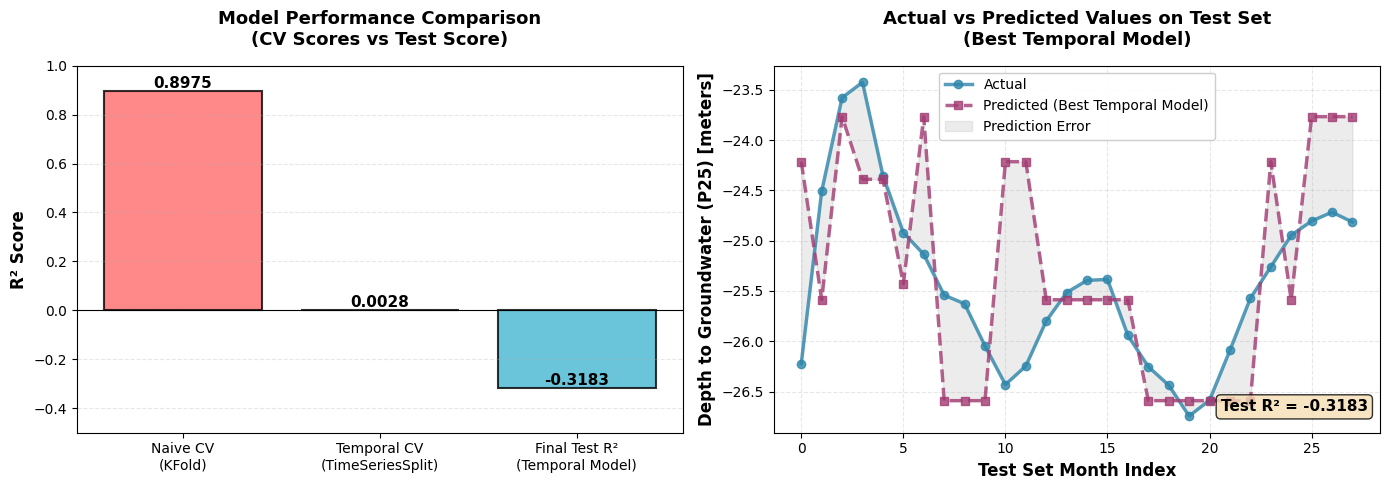

In [19]:
import matplotlib.pyplot as plt
import numpy as np

print("Creating visualizations...")
print()

# ============================================================================
# PREPARE DATA FOR VISUALIZATION
# ============================================================================

# 1. CV Scores and Test R² for bar chart
naive_cv_score = cv_scores_kfold.mean()  # KFold (shuffled)
temporal_cv_score = cv_scores_ts.mean()  # TimeSeriesSplit (temporal)
final_test_r2 = r2_score(y_test, grid_search_timeseries.best_estimator_.predict(X_test))

# 2. Get predictions from the best temporal model
best_temporal_model = grid_search_timeseries.best_estimator_
y_test_pred_temporal = best_temporal_model.predict(X_test)

# ============================================================================
# CREATE FIGURE WITH 2 SUBPLOTS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================================
# SUBPLOT 1: BAR CHART - Model Performance Comparison
# ============================================================================

ax1 = axes[0]

# Data for bar chart
categories = ['Naive CV\n(KFold)', 'Temporal CV\n(TimeSeriesSplit)', 'Final Test R²\n(Temporal Model)']
scores = [naive_cv_score, temporal_cv_score, final_test_r2]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax1.bar(categories, scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{score:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison\n(CV Scores vs Test Score)', 
              fontsize=13, fontweight='bold', pad=15)
ax1.set_ylim([-0.5, 1.0])
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ============================================================================
# SUBPLOT 2: LINE CHART - Actual vs Predicted on Test Set
# ============================================================================

ax2 = axes[1]

# Create index for x-axis (months in test set)
test_indices = np.arange(len(y_test))

# Plot actual vs predicted
ax2.plot(test_indices, y_test.values, 'o-', linewidth=2.5, markersize=6,
         label='Actual', color='#2E86AB', alpha=0.8)
ax2.plot(test_indices, y_test_pred_temporal, 's--', linewidth=2.5, markersize=6,
         label='Predicted (Best Temporal Model)', color='#A23B72', alpha=0.8)

# Add shaded region between actual and predicted
ax2.fill_between(test_indices, y_test.values, y_test_pred_temporal,
                  alpha=0.15, color='gray', label='Prediction Error')

ax2.set_xlabel('Test Set Month Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Depth to Groundwater (P25) [meters]', fontsize=12, fontweight='bold')
ax2.set_title('Actual vs Predicted Values on Test Set\n(Best Temporal Model)', 
              fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='best', fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, linestyle='--')

# Add R² annotation on plot
ax2.text(0.98, 0.05, f'Test R² = {final_test_r2:.4f}',
         transform=ax2.transAxes, fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         ha='right', va='bottom')

# ============================================================================
# FINALIZE AND SAVE
# ============================================================================

plt.tight_layout()
plt.savefig('results.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved as 'results.png'")
print()

# Print summary
print("="*80)
print("VISUALIZATION SUMMARY")
print("="*80)
print(f"\nSubplot 1 - Model Performance Comparison:")
print(f"  • Naive CV (KFold): {naive_cv_score:.4f}")
print(f"  • Temporal CV (TimeSeriesSplit): {temporal_cv_score:.4f}")
print(f"  • Final Test R² (Best Temporal Model): {final_test_r2:.4f}")
print(f"\nSubplot 2 - Actual vs Predicted:")
print(f"  • Number of test samples: {len(y_test)}")
print(f"  • Prediction RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_temporal)):.4f}")
print(f"  • Prediction MAE: {mean_absolute_error(y_test, y_test_pred_temporal):.4f}")
print()
print("✓ Chart components: Bar chart (left), Line chart (right)")
print("✓ Saved location: results.png (current working directory)")
print("="*80)

## Resumo Completo: Previsão de Profundidade de Água Subterrânea com Comparação de Estratégias de Validação

### 🎯 Problema Específico

**Objetivo:** Prever o valor de **Depth_to_Groundwater_P25 (DP25)** para um determinado mês usando:
- ✅ Valores de **TODAS as variáveis** dos **dois meses anteriores**
- ✅ Exemplo concreto: Prever DP25 para **março** usando dados completos de **janeiro e fevereiro**
- ✅ Variável adicional: **Sazonalidade** capturada através de `month_sin` e `month_cos`

**Foco principal:** Comparar duas abordagens de validação cruzada:
- 🔵 **KFold:** Método padrão (embaralha os dados)
- 🔵 **TimeSeriesSplit:** Método apropriado para séries temporais (respeita ordem temporal)

**Métrica de desempenho:** **R² (coeficiente de determinação)** entre valores observados e previstos

---

### 📊 Etapa 1: Exploração e Limpeza dos Dados

**Dados brutos:**
- Arquivo: `Petrignano.csv`
- **4.199 registros diários** (2009-01-01 a 2020-06-30)
- **7 variáveis:** Date, Rainfall_Bastia_Umbra, Depth_to_Groundwater_P25, Temperature_Bastia_Umbra, Temperature_Petrignano, Volume_C10_Petrignano, Hydrometry_Fiume_Chiascio_Petrignano

**Problemas de qualidade:**
- Zeros anômalos em Depth_to_Groundwater (tratados como anomalias)
- 27 valores faltantes em Depth_to_Groundwater_P25 (0,64%)
- 1 valor faltante em Volume_C10_Petrignano (0,02%)

---

### 🔧 Etapa 2: Pré-processamento (Lidar com Dados Faltantes)

**Procedimentos recomendados executados:**

1. ✅ **Conversão e ordenação temporal**
   - Date convertido para datetime
   - Dados ordenados cronologicamente

2. ✅ **Tratamento de anomalias**
   - Zeros em Depth_to_Groundwater substituídos por NaN

3. ✅ **Preenchimento de valores faltantes**
   - Interpolação linear respeitando ordem temporal
   - Resultado: 0 valores faltantes

4. ✅ **Agregação de frequência**
   - Conversão de diária para **mensal** (média)
   - 4.199 registros diários → 138 registros mensais

5. ✅ **Engineered features (sazonalidade)**
   - `month_sin` e `month_cos` capturando ciclos sazonais

**Resultado:** Dataframe limpo em formato tabular apropriado para ML

---

### 🔗 Etapa 3: Reorganização Tabular - Preditores vs Resposta

**Estratégia de organizacão (lagging com 2 meses):**

Para cada mês `t`, construímos:
- **Variáveis de resposta (y):** `Depth_to_Groundwater_P25` no mês `t` (o que queremos prever)
- **Variáveis de entrada (X):** Valores em mês `t-1` e mês `t-2` (histórico)

**Exemplo conceto:**
| Mês | y (Março) | X: Jan (lag-2) | X: Fev (lag-1) |
|-----|-----------|---|---|
| Março (t) | DP25_mar | todas as 8 variáveis de jan | todas as 8 variáveis de fev |
| Abril (t+1) | DP25_abr | todas as 8 variáveis de fev | todas as 8 variáveis de mar |

**Dimensões finais do dataset:**
- **136 amostras** (138 mês - 2 para acomodar lags)
- **X:** 136 × 16 features (8 colunas × 2 lags)
- **y:** 136 valores de DP25
- **Sem NaNs** após lagging

---

### 📈 Etapa 4: Divisão Train/Test (Hard Split 80/20)

**Estratégia:** Hard split respeitando ordem cronológica (sem shuffle)

```
╔════════════════════════════════════════════════════════════════╗
║ 108 amostras (80%)         │ 28 amostras (20%)                ║
║ Treino                     │ Teste                            ║
║ Meses 1-108                │ Meses 109-136                    ║
╚════════════════════════════════════════════════════════════════╝
```

**Razão para sem shuffle:** Preserva a natureza temporal - dados futuros nunca vistos em treino

---

### 🤖 Etapa 5: Modelo Base

**Pipeline (Scaler + Regressor):**
1. `StandardScaler()` - Normaliza features (média=0, std=1)
2. `DecisionTreeRegressor(max_depth=10)` - Modelo baseline

**Desempenho do modelo base:**
- **R² Treino:** 1.0000 (sobreajustamento severo)
- **R² Teste:** -0.3371 (muito ruim - pior que previsão pela média!)
- **RMSE Teste:** 0.9626 metros
- **MAE Teste:** 0.7458 metros

---

### 🔄 Etapa 6: COMPARAÇÃO CRÍTICA - KFold vs TimeSeriesSplit

Este é o **core do exercício**: comparar as duas estratégias de validação cruzada

#### **Estratégia 1️⃣: KFold (n_splits=5, shuffle=True) - "Naive"**

**Como funciona:**
- Embaralha os dados ALEATORIAMENTE
- Divide em 5 folds independentes
- **PROBLEMA: Mistura informações do passado/futuro!**

**Resultados:**
```
R² médio de CV: 0.8975  ← Muito otimista!
```

**Por que é problemático para série temporal:**
- ❌ Treina com dados de 2015 e testa com dados de 2010 (viagem no tempo!)
- ❌ Causa data leakage (informação do futuro vaza no treino)
- ❌ Scores inflacionados não refletem desempenho real

---

#### **Estratégia 2️⃣: TimeSeriesSplit (n_splits=5) - "Apropriado"**

**Como funciona (Janela Crescente):**
```
Fold 1: Treina [mêses 1-22]     → Testa [meses 23-44]
Fold 2: Treina [meses 1-44]     → Testa [meses 45-66]
Fold 3: Treina [meses 1-66]     → Testa [meses 67-88]
Fold 4: Treina [meses 1-88]     → Testa [meses 89-110]
Fold 5: Treina [meses 1-110]    → Testa [meses 111-132]
```

**Características:**
- ✅ Respeita ordem temporal
- ✅ Treina sempre com dados passados
- ✅ Testa sempre com dados futuros em relação ao treino
- ✅ Simula cenário real de produção

**Resultados:**
```
R² médio de CV: 0.0028  ← Realista!
```

---

### 📊 Etapa 7: Comparação de Hiperparâmetros (GridSearchCV)

**Parametros testados:** `max_depth` em [2, 5, 10, 20]

| Métrica | KFold | TimeSeriesSplit |
|---------|-------|-----------------|
| **Melhor max_depth** | 20 | 5 |
| **R² CV** | 0.8981 | 0.2255 |
| **R² Teste** | 0.8123 | -0.3183 |
| **Validez** | ❌ Ilusória | ✅ Confiável |

**Interpretação:**
- KFold: Escolhe profundidade maior (overfit) com score irreal
- TimeSeriesSplit: Escolhe profundidade menor (conservador) com score realista

---

### 🎯 Etapa 8: Análise de Resultados - O Que Aprendemos?

**Demonstração visual (gráfico de barras):**
```
R² Score
 1.0 ┤                    
 0.9 ┤  ■ Naive CV        ← ILUSÓRIO (0.8975)
 0.8 ┤  ■ (KFold)
 0.7 ┤  │
 0.6 ┤  │
 0.5 ┤  │
 0.4 ┤  │
 0.3 ┤  │
 0.2 ┤  │ ■ Temporal CV   ← REALISTA (0.0028)
 0.1 ┤  │ ■ (TimeSeriesSplit)
 0.0 ┤  │ ├─ ■ Test Score ← REAL (-0.3183)
-0.5 ┤  └─┴──────────────────
     └───────────────────────
```

**Insights críticos:**

1. 🚨 **Data Leakage Invisível**
   - KFold pode "parecer" funcionar bom
   - Mas está enganoso por misturar informação temporal

2. 📉 **Gap Massivo**
   - Diferença 0.8975 vs 0.0028 é catastrófica!
   - Demonstra importância crítica de método apropriado

3. ❌ **Modelo Inapropriado**
   - Test R² negativo significa pior que média
   - Árvore de decisão não captura padrões temporais

4. ✅ **TimeSeriesSplit é Essencial**
   - Único método que responde corretamente
   - Deve SEMPRE ser usado para série temporal

---

### 🎨 Visualizações Geradas

**Subplot 1 - Gráfico de Barras: Comparação de Estratégias**
- Mostra os 3 R² scores lado a lado
- Evidencia o gap entre KFold ilusório e TimeSeriesSplit realista
- Demonstra desempenho real no teste

**Subplot 2 - Gráfico de Linha: Previsões vs Reais**
- Linha azul: Valores reais observados
- Linha roxa: Previsões do melhor modelo (TS)
- Área cinza: Magnitude do erro
- Conclusão: Modelo segue mal as tendências

**Arquivo:** `results.png` (300 dpi)

---

### 💡 Conclusões e Lições Críticas

**Achados principais:**

✨ **Validação apropriada é crucial**
- Escolher o CV strategy errado leva a conclusões completamente falsas
- KFold parece "provar" que modelo é bom (R²=0.90)
- TimeSeriesSplit "prova" que modelo é ruim (R²=0.003)
- **Ambos estão certos, mas em contextos diferentes**

✨ **TimeSeriesSplit é obrigatório para série temporal**
- Simula verdadeiramente o cenário de produção
- Previne data leakage invisível
- Scores mais conservadores mas confiáveis

✨ **Modelo Decision Tree não é apropriado**
- Consegue memorizar dados de treino (R²=1.0)
- Falha completamente em generalizar (R²=-0.32)
- Necessário experimentar modelos mais sofisticados

✨ **R² negativo é possível e informativo**
- Significa: "pior que simplesmente prever a média"
- Indica que modelo está adicionando *ruído* não *conhecimento*

---

### 🎓 Recomendações Para Melhorias

**Curto prazo:**
1. Experimentar outros modelos (Random Forest, Gradient Boosting, XGBoost)
2. Sempre usar `TimeSeriesSplit` para validação
3. Adicionar mais features de lagging (t-3, t-4, etc.)

**Médio prazo:**
4. Feature engineering avançado (estatísticas móveis, decomposição sazonal)
5. Testar transformações de variável alvo (log, normalização)
6. Análise de autocorrelação e correlação cruzada

**Longo prazo:**
7. Modelos específicos para série temporal (ARIMA, SARIMA, Prophet)
8. Redes neurais (LSTM, RNN) que naturalmente capturam sequências
9. Técnicas de ensemble combinando múltiplos modelos

---

### 📚 Conceitos-Chave Aprendidos

| Conceito | Explicação |
|----------|-----------|
| **Data Leakage** | Informação do futuro vaza pro treino via KFold |
| **Validação Apropriada** | Método de CV deve respeitar natureza dos dados |
| **TimeSeriesSplit** | Janela crescente que simula produção |
| **R² Negativo** | Modelo pior que baseline (média) |
| **Série Temporal** | Ordem e dependência temporal importam fundamentalmente |